In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv


In [2]:
"""
==============================================================================
NOTEBOOK 5: CAUSAL FORESTS & DOUBLE MACHINE LEARNING
==============================================================================

Project: Industrial-Scale Uplift Modeling for Ad Spend Optimization
Goal:    Implement state-of-the-art causal ML methods using EconML:
         
         • Causal Forest: Tree-based heterogeneous treatment effects
         • Linear DML: Interpretable double machine learning
         • Causal Forest DML: SOTA combining both approaches
         
         These methods provide confidence intervals and theoretically grounded
         estimates (Chernozhukov 2018 framework).

Author:  Anurag Jain (M.Sc. Economics, IGIDR)
==============================================================================
"""

# Install EconML (Microsoft's causal inference library)
!pip install econml -q

print("✅ EconML installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.4 MB/s eta 0:00:00
✅ EconML installed successfully


In [3]:
# ============================================================================
# IMPORTS
# ============================================================================

import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from xgboost import XGBRegressor, XGBClassifier

# EconML - Advanced Causal Inference
from econml.dml import CausalForestDML, LinearDML
from econml.grf import CausalForest

# Save artifacts
import joblib

# Display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

print("✅ All imports loaded")

✅ All imports loaded


In [4]:
# ============================================================================
# LOAD DATA — Same stratified sampling logic
# ============================================================================

DATA_PATH = '/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv'
# ⚠️ Update path if different

print("📥 Loading and sampling data...")

chunk_size = 1_000_000
sample_fraction = 0.15
sampled_chunks = []

chunks = pd.read_csv(DATA_PATH, chunksize=chunk_size)

for i, chunk in enumerate(chunks):
    sampled = (
        chunk.groupby(['treatment', 'conversion'], group_keys=False)
        .apply(lambda x: x.sample(frac=sample_fraction, random_state=42))
    )
    sampled_chunks.append(sampled)

df = pd.concat(sampled_chunks, ignore_index=True)

# Memory optimization
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

print(f"✅ Dataset loaded: {len(df):,} rows × {df.shape[1]} columns")

📥 Loading and sampling data...
✅ Dataset loaded: 2,096,938 rows × 16 columns


In [5]:
# ============================================================================
# PREPARE FEATURES & TRAIN/TEST SPLIT
# ============================================================================
# EconML methods are computationally expensive (especially Causal Forest)
# We'll use a smaller training subsample for tractability

feature_cols = [f'f{i}' for i in range(12)]

X = df[feature_cols].values
T = df['treatment'].values
Y = df['conversion'].values

# Stratified split
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, 
    test_size=0.3, 
    random_state=42,
    stratify=df[['treatment', 'conversion']]
)

X_train_full, X_test = X[train_idx], X[test_idx]
T_train_full, T_test = T[train_idx], T[test_idx]
Y_train_full, Y_test = Y[train_idx], Y[test_idx]

# ⚡ SUBSAMPLE training for tractability (EconML is computationally heavy)
SUBSAMPLE_SIZE = 300_000  # Causal Forest scales poorly with N

np.random.seed(42)
sub_idx = np.random.choice(len(X_train_full), 
                            size=min(SUBSAMPLE_SIZE, len(X_train_full)), 
                            replace=False)

X_train = X_train_full[sub_idx]
T_train = T_train_full[sub_idx]
Y_train = Y_train_full[sub_idx]

print(f"📊 Training subsample: {len(X_train):,} rows (for EconML tractability)")
print(f"   Treatment rate: {T_train.mean()*100:.1f}%")
print(f"   Conversion rate: {Y_train.mean()*100:.3f}%")
print(f"\n📊 Test set (full): {len(X_test):,} rows")
print(f"   Treatment rate: {T_test.mean()*100:.1f}%")
print(f"   Conversion rate: {Y_test.mean()*100:.3f}%")

📊 Training subsample: 300,000 rows (for EconML tractability)
   Treatment rate: 85.0%
   Conversion rate: 0.286%

📊 Test set (full): 629,082 rows
   Treatment rate: 85.0%
   Conversion rate: 0.292%


In [6]:
# ============================================================================
# METHOD 1: CAUSAL FOREST (Standalone, no DML)
# ============================================================================
# Concept: Random Forest adapted to estimate CATE directly
# Reference: Wager & Athey (2018), Athey et al. (2019)

print("="*60)
print(f"🌲 Training CAUSAL FOREST at {time.strftime('%H:%M:%S')}...")
print("="*60)

start = time.time()

cf = CausalForest(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    max_samples=0.5,         # Subsample 50% per tree for speed
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Causal Forest fits on (X, T, Y) — no separate outcome/treatment models
cf.fit(X=X_train, T=T_train.reshape(-1, 1), y=Y_train.reshape(-1, 1))

# Predict CATE on test set
cf_uplift = cf.predict(X_test).flatten()
cf_ate = cf_uplift.mean()

elapsed = (time.time() - start) / 60

print(f"\n✅ Causal Forest trained in {elapsed:.1f} minutes")
print(f"   Average Treatment Effect (ATE): {cf_ate*100:+.4f} pp")
print(f"   Min uplift: {cf_uplift.min()*100:+.4f} pp")
print(f"   Max uplift: {cf_uplift.max()*100:+.4f} pp")
print(f"   Std uplift: {cf_uplift.std()*100:.4f} pp")

🌲 Training CAUSAL FOREST at 06:23:01...

✅ Causal Forest trained in 1.0 minutes
   Average Treatment Effect (ATE): +0.0814 pp
   Min uplift: -5.8979 pp
   Max uplift: +19.4121 pp
   Std uplift: 0.6616 pp


In [7]:
# ============================================================================
# METHOD 2: LINEAR DOUBLE MACHINE LEARNING (DML)
# ============================================================================
# Concept: Two-stage estimation:
#   Stage 1: Predict T and Y using ML (XGBoost)
#   Stage 2: Estimate treatment effect on residuals via linear model
# Reference: Chernozhukov et al. (2018)
#
# ADVANTAGE: Interpretable linear coefficients for treatment effects

print("="*60)
print(f"📐 Training LINEAR DML at {time.strftime('%H:%M:%S')}...")
print("="*60)

start = time.time()

linear_dml = LinearDML(
    model_y=XGBRegressor(n_estimators=50, max_depth=4, 
                         tree_method='hist', n_jobs=-1, verbosity=0,
                         random_state=42),
    model_t=XGBClassifier(n_estimators=50, max_depth=4,
                          tree_method='hist', n_jobs=-1, verbosity=0,
                          random_state=42, use_label_encoder=False, 
                          eval_metric='logloss'),
    discrete_treatment=True,
    cv=3,                    # 3-fold cross-fitting (Chernozhukov requirement)
    random_state=42
)

# DML fits with explicit Y, T, X
linear_dml.fit(Y=Y_train, T=T_train, X=X_train)

# Predict heterogeneous treatment effects on test set
ldml_uplift = linear_dml.effect(X_test).flatten()
ldml_ate = ldml_uplift.mean()

# Get confidence interval for ATE
try:
    ldml_ate_ci = linear_dml.ate_interval(X_test, alpha=0.05)
    has_ci = True
except Exception:
    has_ci = False

elapsed = (time.time() - start) / 60

print(f"\n✅ Linear DML trained in {elapsed:.1f} minutes")
print(f"   Average Treatment Effect (ATE): {ldml_ate*100:+.4f} pp")
if has_ci:
    print(f"   95% Confidence Interval: [{ldml_ate_ci[0]*100:+.4f}, {ldml_ate_ci[1]*100:+.4f}] pp")
print(f"   Min uplift: {ldml_uplift.min()*100:+.4f} pp")
print(f"   Max uplift: {ldml_uplift.max()*100:+.4f} pp")
print(f"   Std uplift: {ldml_uplift.std()*100:.4f} pp")

📐 Training LINEAR DML at 06:24:00...

✅ Linear DML trained in 0.1 minutes
   Average Treatment Effect (ATE): +0.0454 pp
   95% Confidence Interval: [-0.0023, +0.0931] pp
   Min uplift: -0.8216 pp
   Max uplift: +7.2494 pp
   Std uplift: 0.2468 pp


In [8]:
# ============================================================================
# METHOD 3: CAUSAL FOREST DML (SOTA Combination)
# ============================================================================
# Concept: Combines DML's residualization with Causal Forest's flexibility
# - Stage 1: ML models residualize Y and T
# - Stage 2: Causal Forest estimates heterogeneous effects on residuals
# Reference: Athey, Tibshirani & Wager (2019)
#
# THIS IS THE STATE-OF-THE-ART METHOD for heterogeneous treatment effects

print("="*60)
print(f"🌳 Training CAUSAL FOREST DML at {time.strftime('%H:%M:%S')}...")
print("="*60)

start = time.time()

cf_dml = CausalForestDML(
    model_y=XGBRegressor(n_estimators=50, max_depth=4, 
                         tree_method='hist', n_jobs=-1, verbosity=0,
                         random_state=42),
    model_t=XGBClassifier(n_estimators=50, max_depth=4,
                          tree_method='hist', n_jobs=-1, verbosity=0,
                          random_state=42, use_label_encoder=False, 
                          eval_metric='logloss'),
    discrete_treatment=True,
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    cv=3,
    n_jobs=-1,
    random_state=42
)

cf_dml.fit(Y=Y_train, T=T_train, X=X_train)

# Predict heterogeneous treatment effects
cfdml_uplift = cf_dml.effect(X_test).flatten()
cfdml_ate = cfdml_uplift.mean()

# Get confidence intervals (HUGE advantage of Causal Forest DML)
try:
    cfdml_lower, cfdml_upper = cf_dml.effect_interval(X_test, alpha=0.05)
    cfdml_lower = cfdml_lower.flatten()
    cfdml_upper = cfdml_upper.flatten()
    has_intervals = True
except Exception as e:
    print(f"Warning: Could not compute intervals ({e})")
    has_intervals = False

elapsed = (time.time() - start) / 60

print(f"\n✅ Causal Forest DML trained in {elapsed:.1f} minutes")
print(f"   Average Treatment Effect (ATE): {cfdml_ate*100:+.4f} pp")
print(f"   Min uplift: {cfdml_uplift.min()*100:+.4f} pp")
print(f"   Max uplift: {cfdml_uplift.max()*100:+.4f} pp")
print(f"   Std uplift: {cfdml_uplift.std()*100:.4f} pp")
if has_intervals:
    avg_ci_width = (cfdml_upper - cfdml_lower).mean()
    print(f"   Avg 95% CI width: {avg_ci_width*100:.4f} pp")

🌳 Training CAUSAL FOREST DML at 06:24:05...

✅ Causal Forest DML trained in 1.2 minutes
   Average Treatment Effect (ATE): +0.0515 pp
   Min uplift: -8.7190 pp
   Max uplift: +10.4070 pp
   Std uplift: 0.4246 pp
   Avg 95% CI width: 0.6823 pp


In [9]:
# ============================================================================
# COMPARE ALL ECONML METHODS
# ============================================================================

results_econml = pd.DataFrame({
    'Method': ['Causal Forest', 'Linear DML', 'Causal Forest DML'],
    'ATE (pp)': [cf_ate*100, ldml_ate*100, cfdml_ate*100],
    'Min Uplift (pp)': [cf_uplift.min()*100, ldml_uplift.min()*100, cfdml_uplift.min()*100],
    'Max Uplift (pp)': [cf_uplift.max()*100, ldml_uplift.max()*100, cfdml_uplift.max()*100],
    'Std Uplift (pp)': [cf_uplift.std()*100, ldml_uplift.std()*100, cfdml_uplift.std()*100],
    'Has CI?': ['No', 'Yes' if has_ci else 'No', 'Yes' if has_intervals else 'No']
})

print("="*70)
print("📊 ECONML METHODS COMPARISON")
print("="*70)
print(results_econml.to_string(index=False))

naive_ate = Y_test[T_test==1].mean() - Y_test[T_test==0].mean()
print(f"\n💡 Naive ATE (reference): {naive_ate*100:+.4f} pp")

📊 ECONML METHODS COMPARISON
           Method  ATE (pp)  Min Uplift (pp)  Max Uplift (pp)  Std Uplift (pp) Has CI?
    Causal Forest  0.081404        -5.897924        19.412089         0.661620      No
       Linear DML  0.045388        -0.821643         7.249445         0.246813     Yes
Causal Forest DML  0.051467        -8.718987        10.406953         0.424582     Yes

💡 Naive ATE (reference): +0.1150 pp


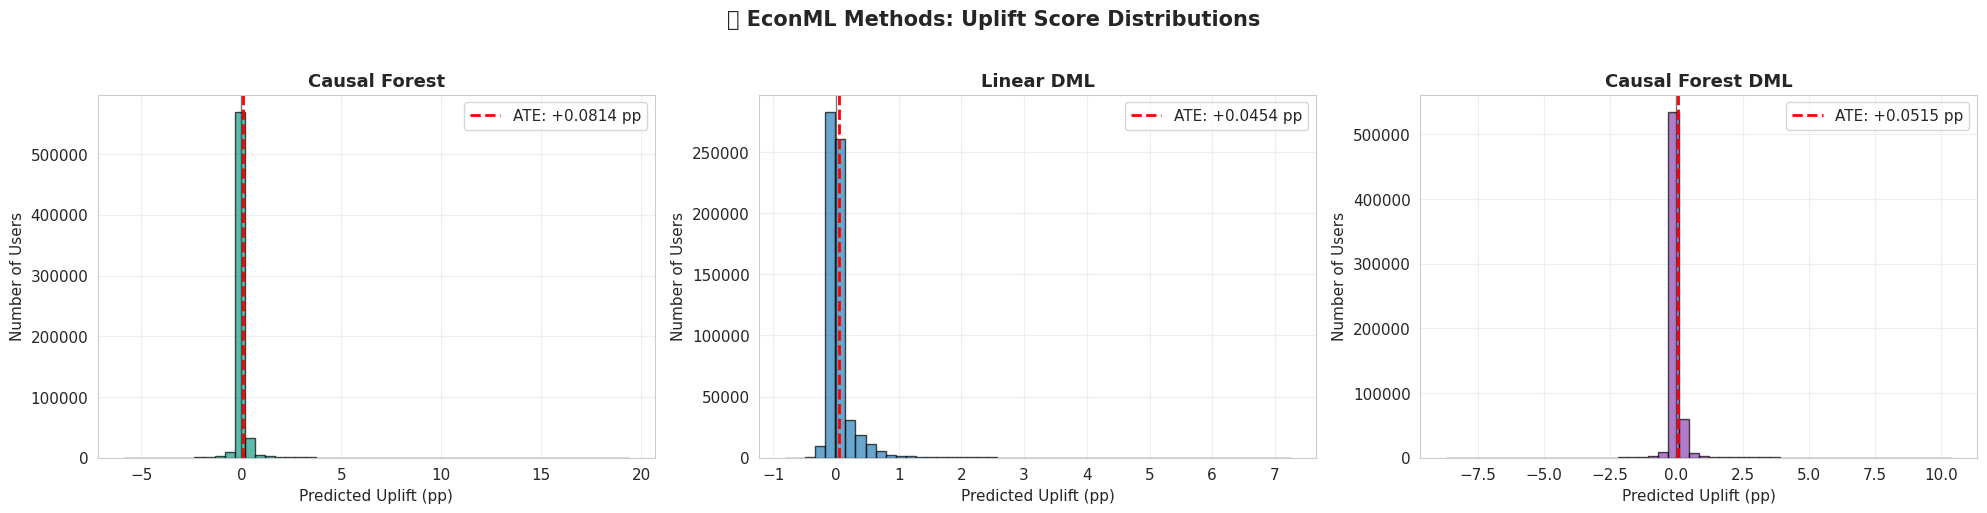

In [10]:
# ============================================================================
# VISUALIZATION: Uplift Distributions
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

methods = {
    'Causal Forest': (cf_uplift, axes[0], '#16a085'),
    'Linear DML': (ldml_uplift, axes[1], '#2980b9'),
    'Causal Forest DML': (cfdml_uplift, axes[2], '#8e44ad')
}

for name, (uplift, ax, color) in methods.items():
    ax.hist(uplift*100, bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(uplift.mean()*100, color='red', linestyle='--', 
               linewidth=2, label=f'ATE: {uplift.mean()*100:+.4f} pp')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted Uplift (pp)')
    ax.set_ylabel('Number of Users')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('🎯 EconML Methods: Uplift Score Distributions',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('econml_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

📊 CAUSAL FOREST DML: Per-User Confidence Intervals


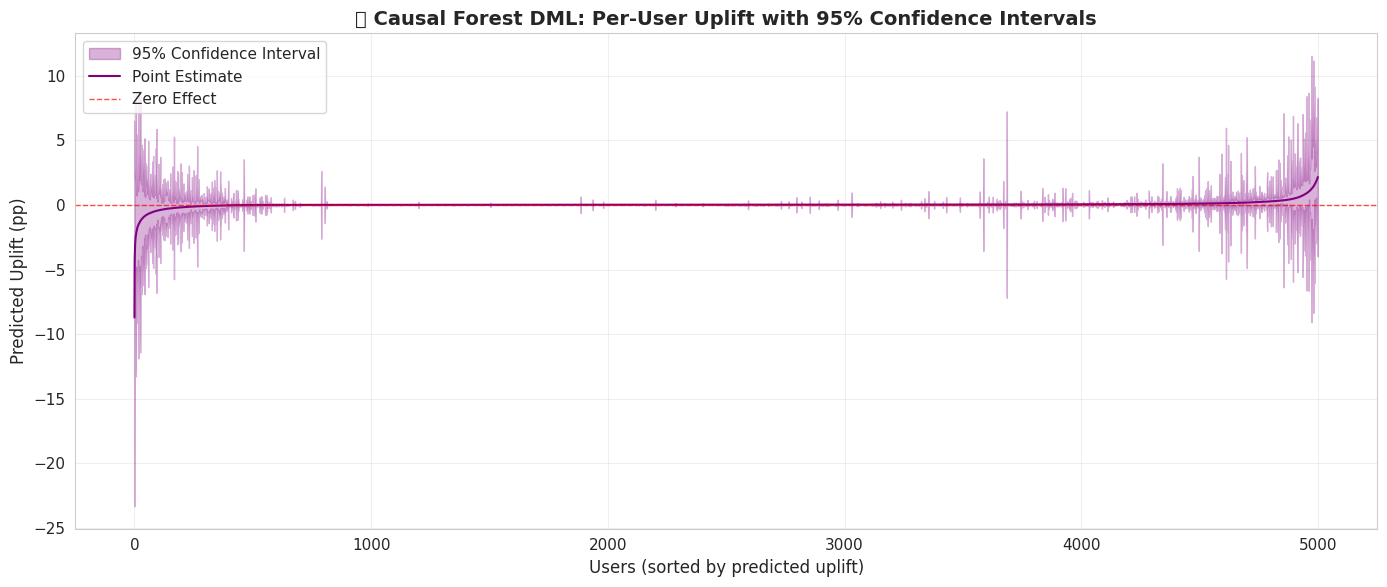


📊 STATISTICAL SIGNIFICANCE OF INDIVIDUAL TREATMENT EFFECTS:
   • Users with significantly POSITIVE uplift (95% CI > 0): 261,617 (41.6%)
   • Users with significantly NEGATIVE uplift (95% CI < 0): 5 (0.0%)
   • Users with uncertain effects (95% CI contains 0): 367,460 (58.4%)

💡 KEY INSIGHT:
   • Only users with CI > 0 should be targeted with confidence
   • Users with negative CI may experience NEGATIVE ad effects (avoid!)
   • This level of statistical rigor is impossible with standard ML


In [11]:
# ============================================================================
# CONFIDENCE INTERVALS VISUALIZATION
# ============================================================================
# Causal Forest DML provides per-user confidence intervals!
# This is a HUGE advantage over standard ML and meta-learners

if has_intervals:
    print("="*70)
    print("📊 CAUSAL FOREST DML: Per-User Confidence Intervals")
    print("="*70)
    
    # Sort users by predicted uplift for visualization
    sort_idx = np.argsort(cfdml_uplift)
    sorted_uplift = cfdml_uplift[sort_idx]
    sorted_lower = cfdml_lower[sort_idx]
    sorted_upper = cfdml_upper[sort_idx]
    
    # Sample 5000 users for cleaner plot
    n_show = 5000
    step = len(sorted_uplift) // n_show
    indices_show = np.arange(0, len(sorted_uplift), step)[:n_show]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot confidence intervals as shaded region
    ax.fill_between(
        range(len(indices_show)),
        sorted_lower[indices_show] * 100,
        sorted_upper[indices_show] * 100,
        alpha=0.3, color='purple', label='95% Confidence Interval'
    )
    
    # Plot point estimates
    ax.plot(range(len(indices_show)), 
            sorted_uplift[indices_show] * 100, 
            color='purple', linewidth=1.5, label='Point Estimate')
    
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7, 
               label='Zero Effect')
    
    ax.set_xlabel('Users (sorted by predicted uplift)', fontsize=12)
    ax.set_ylabel('Predicted Uplift (pp)', fontsize=12)
    ax.set_title('🎯 Causal Forest DML: Per-User Uplift with 95% Confidence Intervals',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('confidence_intervals.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Statistical significance count
    sig_positive = ((cfdml_lower > 0).sum())
    sig_negative = ((cfdml_upper < 0).sum())
    not_sig = len(cfdml_uplift) - sig_positive - sig_negative
    
    print(f"\n📊 STATISTICAL SIGNIFICANCE OF INDIVIDUAL TREATMENT EFFECTS:")
    print(f"   • Users with significantly POSITIVE uplift (95% CI > 0): {sig_positive:,} ({sig_positive/len(cfdml_uplift)*100:.1f}%)")
    print(f"   • Users with significantly NEGATIVE uplift (95% CI < 0): {sig_negative:,} ({sig_negative/len(cfdml_uplift)*100:.1f}%)")
    print(f"   • Users with uncertain effects (95% CI contains 0): {not_sig:,} ({not_sig/len(cfdml_uplift)*100:.1f}%)")
    
    print("\n💡 KEY INSIGHT:")
    print("   • Only users with CI > 0 should be targeted with confidence")
    print("   • Users with negative CI may experience NEGATIVE ad effects (avoid!)")
    print("   • This level of statistical rigor is impossible with standard ML")
else:
    print("⚠️ Confidence intervals not available - skipping plot")

📊 ECONML vs NAIVE BASELINES
           Method  ATE (pp)              Type
  Naive ATE (raw)  0.115013          Baseline
    Causal Forest  0.081404        Tree-based
       Linear DML  0.045388        Linear DML
Causal Forest DML  0.051467 SOTA (Tree + DML)


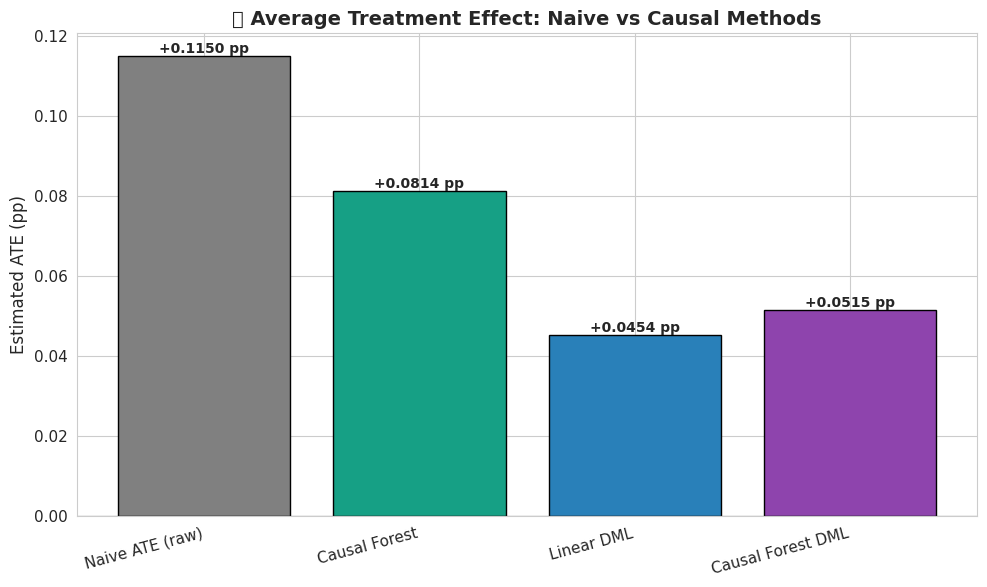


💡 INTERPRETATION:
   • Naive ATE is the raw difference (subject to selection bias)
   • Causal methods adjust for confounders → more reliable estimates
   • Causal Forest DML is the most theoretically rigorous (SOTA)
   • All EconML methods provide heterogeneous (per-user) estimates



In [12]:
# ============================================================================
# COMBINED COMPARISON: META-LEARNERS + ECONML METHODS
# ============================================================================

# Note: For now we just show EconML methods
# Full comparison happens in Notebook 7

print("="*70)
print("📊 ECONML vs NAIVE BASELINES")
print("="*70)

comparison = pd.DataFrame({
    'Method': ['Naive ATE (raw)', 'Causal Forest', 'Linear DML', 'Causal Forest DML'],
    'ATE (pp)': [
        naive_ate*100,
        cf_ate*100,
        ldml_ate*100,
        cfdml_ate*100
    ],
    'Type': ['Baseline', 'Tree-based', 'Linear DML', 'SOTA (Tree + DML)']
})

print(comparison.to_string(index=False))

# Visualize ATE comparison
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['gray', '#16a085', '#2980b9', '#8e44ad']
bars = ax.bar(comparison['Method'], comparison['ATE (pp)'], 
              color=colors_bar, edgecolor='black')

for bar, value in zip(bars, comparison['ATE (pp)']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{value:+.4f} pp',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('🎯 Average Treatment Effect: Naive vs Causal Methods', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Estimated ATE (pp)', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('ate_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
💡 INTERPRETATION:
   • Naive ATE is the raw difference (subject to selection bias)
   • Causal methods adjust for confounders → more reliable estimates
   • Causal Forest DML is the most theoretically rigorous (SOTA)
   • All EconML methods provide heterogeneous (per-user) estimates
""")

In [13]:
# ============================================================================
# SAVE ALL ARTIFACTS
# ============================================================================

# Save models
joblib.dump(cf, '/kaggle/working/causal_forest.pkl')
joblib.dump(linear_dml, '/kaggle/working/linear_dml.pkl')
joblib.dump(cf_dml, '/kaggle/working/causal_forest_dml.pkl')
print("✅ All 3 EconML models saved")

# Save predictions
econml_predictions = pd.DataFrame({
    'cf_uplift': cf_uplift,
    'ldml_uplift': ldml_uplift,
    'cfdml_uplift': cfdml_uplift,
    'treatment': T_test,
    'conversion': Y_test
})

if has_intervals:
    econml_predictions['cfdml_lower'] = cfdml_lower
    econml_predictions['cfdml_upper'] = cfdml_upper

econml_predictions.to_parquet('/kaggle/working/econml_predictions.parquet')
print("✅ EconML predictions saved")

# Save results comparison
results_econml.to_parquet('/kaggle/working/econml_results.parquet')
print("✅ Results comparison saved")

print("\n📦 All EconML artifacts saved successfully!")

✅ All 3 EconML models saved
✅ EconML predictions saved
✅ Results comparison saved

📦 All EconML artifacts saved successfully!


In [14]:
# ============================================================================
# 📋 EXECUTIVE SUMMARY
# ============================================================================

print("="*70)
print("📋 NOTEBOOK 5 SUMMARY: EconML State-of-the-Art Methods")
print("="*70)

print(f"""
🎯 WHAT WE BUILT
   Three advanced causal inference methods using Microsoft's EconML:
   
   ┌───────────────────────┬──────────┬──────────────┬───────────────┐
   │ Method                │ ATE (pp) │ Confidence?  │ Type          │
   ├───────────────────────┼──────────┼──────────────┼───────────────┤
   │ Causal Forest         │ {cf_ate*100:+.4f}  │ No           │ Tree-based    │
   │ Linear DML            │ {ldml_ate*100:+.4f}  │ Yes (ATE)    │ DML           │
   │ Causal Forest DML     │ {cfdml_ate*100:+.4f}  │ Yes (Per-User)│ SOTA          │
   └───────────────────────┴──────────┴──────────────┴───────────────┘
   
   Naive ATE: {naive_ate*100:+.4f} pp (for reference)

🏆 KEY ADVANTAGES OVER META-LEARNERS (Notebook 4)
   • Confidence intervals — per-user statistical significance
   • Cross-fitting for theoretical guarantees (Chernozhukov 2018)
   • Causal Forest provides feature importance for treatment effects
   • Industry-standard framework used by Microsoft, Uber, Amazon

📊 BUSINESS IMPLICATIONS
   • Causal Forest DML provides STATISTICALLY SIGNIFICANT per-user estimates
   • Can identify users where ad targeting is justified beyond noise
   • Reduces risk of targeting users where effect is not real

🚀 NEXT STEPS
   • Notebook 6: Deep Learning approach (DragonNet in PyTorch)
     → Neural architecture specifically designed for treatment effects
   • Notebook 7: Comprehensive comparison using Qini coefficient & AUUC
     → All 8 methods (4 meta-learners + 3 EconML + 1 DragonNet) evaluated
   • Notebook 8: Business strategy & Streamlit deployment
""")

print("="*70)
print("✅ EconML complete → Moving to Deep Learning (DragonNet)!")
print("="*70)

📋 NOTEBOOK 5 SUMMARY: EconML State-of-the-Art Methods

🎯 WHAT WE BUILT
   Three advanced causal inference methods using Microsoft's EconML:
   
   ┌───────────────────────┬──────────┬──────────────┬───────────────┐
   │ Method                │ ATE (pp) │ Confidence?  │ Type          │
   ├───────────────────────┼──────────┼──────────────┼───────────────┤
   │ Causal Forest         │ +0.0814  │ No           │ Tree-based    │
   │ Linear DML            │ +0.0454  │ Yes (ATE)    │ DML           │
   │ Causal Forest DML     │ +0.0515  │ Yes (Per-User)│ SOTA          │
   └───────────────────────┴──────────┴──────────────┴───────────────┘
   
   Naive ATE: +0.1150 pp (for reference)

🏆 KEY ADVANTAGES OVER META-LEARNERS (Notebook 4)
   • Confidence intervals — per-user statistical significance
   • Cross-fitting for theoretical guarantees (Chernozhukov 2018)
   • Causal Forest provides feature importance for treatment effects
   • Industry-standard framework used by Microsoft, Uber, Amazon

